# Practical Application III: Comparing Classifiers

**Overview**: In this practical application, your goal is to compare the performance of the classifiers we encountered in this section, namely K Nearest Neighbor, Logistic Regression, Decision Trees, and Support Vector Machines.  We will utilize a dataset related to marketing bank products over the telephone.  



### Getting Started

Our dataset comes from the UCI Machine Learning repository [link](https://archive.ics.uci.edu/ml/datasets/bank+marketing).  The data is from a Portugese banking institution and is a collection of the results of multiple marketing campaigns.  We will make use of the article accompanying the dataset [here](CRISP-DM-BANK.pdf) for more information on the data and features.



### Problem 1: Understanding the Data

To gain a better understanding of the data, please read the information provided in the UCI link above, and examine the **Materials and Methods** section of the paper.  How many marketing campaigns does this data represent?

In [1]:
print('data represents 17 campaigns that occurred between May 2008 and November 2010')

data represents 17 campaigns that occurred between May 2008 and November 2010


### Problem 2: Read in the Data

Use pandas to read in the dataset `bank-additional-full.csv` and assign to a meaningful variable name.

In [3]:
import pandas as pd

In [4]:
#  READ CSV FILE FROM GOOGLE DRIVE

from pydrive2.auth import GoogleAuth
from pydrive2.drive import GoogleDrive
from google.colab import auth
from oauth2client.client import GoogleCredentials

# Authenticate and create the PyDrive client.
auth.authenticate_user()
gauth = GoogleAuth()
gauth.credentials = GoogleCredentials.get_application_default()
drive = GoogleDrive(gauth)

link = 'https://drive.google.com/file/d/1wjcs2U6R_eLB7uQj5fYxQ-Ps4pg1Km4C/view?usp=drive_link'
id = link.split("/")[-2] #get file id to read in

downloaded = drive.CreateFile({'id':id})
downloaded.GetContentFile('bank-additional-full.csv')

df_bank_mktg = pd.read_csv('bank-additional-full.csv', sep=';', quotechar='"')

In [9]:
df_bank_mktg.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,...,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,y
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
2,37,services,married,high.school,no,yes,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no
4,56,services,married,high.school,no,no,yes,telephone,may,mon,...,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,no


### Problem 3: Understanding the Features


Examine the data description below, and determine if any of the features are missing values or need to be coerced to a different data type.


```
Input variables:
# bank client data:
1 - age (numeric)
2 - job : type of job (categorical: 'admin.','blue-collar','entrepreneur','housemaid','management','retired','self-employed','services','student','technician','unemployed','unknown')
3 - marital : marital status (categorical: 'divorced','married','single','unknown'; note: 'divorced' means divorced or widowed)
4 - education (categorical: 'basic.4y','basic.6y','basic.9y','high.school','illiterate','professional.course','university.degree','unknown')
5 - default: has credit in default? (categorical: 'no','yes','unknown')
6 - housing: has housing loan? (categorical: 'no','yes','unknown')
7 - loan: has personal loan? (categorical: 'no','yes','unknown')
# related with the last contact of the current campaign:
8 - contact: contact communication type (categorical: 'cellular','telephone')
9 - month: last contact month of year (categorical: 'jan', 'feb', 'mar', ..., 'nov', 'dec')
10 - day_of_week: last contact day of the week (categorical: 'mon','tue','wed','thu','fri')
11 - duration: last contact duration, in seconds (numeric). Important note: this attribute highly affects the output target (e.g., if duration=0 then y='no'). Yet, the duration is not known before a call is performed. Also, after the end of the call y is obviously known. Thus, this input should only be included for benchmark purposes and should be discarded if the intention is to have a realistic predictive model.
# other attributes:
12 - campaign: number of contacts performed during this campaign and for this client (numeric, includes last contact)
13 - pdays: number of days that passed by after the client was last contacted from a previous campaign (numeric; 999 means client was not previously contacted)
14 - previous: number of contacts performed before this campaign and for this client (numeric)
15 - poutcome: outcome of the previous marketing campaign (categorical: 'failure','nonexistent','success')
# social and economic context attributes
16 - emp.var.rate: employment variation rate - quarterly indicator (numeric)
17 - cons.price.idx: consumer price index - monthly indicator (numeric)
18 - cons.conf.idx: consumer confidence index - monthly indicator (numeric)
19 - euribor3m: euribor 3 month rate - daily indicator (numeric)
20 - nr.employed: number of employees - quarterly indicator (numeric)

Output variable (desired target):
21 - y - has the client subscribed a term deposit? (binary: 'yes','no')
```



In [5]:
recs = len(df_bank_mktg)
print('Bank Mktg Campaing data contains', recs, 'records')
try:
  df_bank_mktg['y'] = df_bank_mktg['y'].str.replace('yes', '1')
except:
  pass
try:
  df_bank_mktg['y'] = df_bank_mktg['y'].str.replace('no', '0')
except:
  pass
df_bank_mktg['y'] = pd.to_numeric(df_bank_mktg['y'], errors='coerce')
df_bank_mktg = df_bank_mktg.dropna()
recs_no_nulls = len(df_bank_mktg)
print('removing', recs-recs_no_nulls, 'records with missing values')
print('Bank Mktg Campaing data contains', recs_no_nulls, 'records after removing missing values')

# df_bank_mktg = df_bank_mktg.drop(columns=['campaign'])
df_bank_mktg = df_bank_mktg.replace(999, 0)

# remove duration as it is related to the call that may result in the conversion
# and is not known apriory, i.e. can not be used in real life model
df_bank_mktg = df_bank_mktg.drop(columns=['duration'])

# remove campaigns with 0 contacts
# Remove campaigns with 0 contacts from dataset (ROW filtering)
print('Number of records before campaign cleanup:', len(df_bank_mktg))
ct = pd.crosstab(df_bank_mktg['campaign'], df_bank_mktg['y'], margins=True, normalize='index').reset_index()
# Find campaign values that have 0 contacts (where column '1' has value 0)
zero_conversion_campaign_values = ct[ct[1] == 0]['campaign'].reset_index(drop=True)

# Apply row filtering to both X and y
mask_campaign_filter = ~df_bank_mktg['campaign'].isin(zero_conversion_campaign_values)
df_bank_mktg = df_bank_mktg[mask_campaign_filter]

print('Number of records after campaign cleanup:', len(df_bank_mktg))

Bank Mktg Campaing data contains 41188 records
removing 0 records with missing values
Bank Mktg Campaing data contains 41188 records after removing missing values
Number of records before campaign cleanup: 41188
Number of records after campaign cleanup: 40907


### Problem 4: Understanding the Task

After examining the description and data, your goal now is to clearly state the *Business Objective* of the task.  State the objective below.

In [6]:
df_bank_mktg.info()

<class 'pandas.core.frame.DataFrame'>
Index: 40907 entries, 0 to 41187
Data columns (total 20 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   age             40907 non-null  int64  
 1   job             40907 non-null  object 
 2   marital         40907 non-null  object 
 3   education       40907 non-null  object 
 4   default         40907 non-null  object 
 5   housing         40907 non-null  object 
 6   loan            40907 non-null  object 
 7   contact         40907 non-null  object 
 8   month           40907 non-null  object 
 9   day_of_week     40907 non-null  object 
 10  campaign        40907 non-null  int64  
 11  pdays           40907 non-null  int64  
 12  previous        40907 non-null  int64  
 13  poutcome        40907 non-null  object 
 14  emp.var.rate    40907 non-null  float64
 15  cons.price.idx  40907 non-null  float64
 16  cons.conf.idx   40907 non-null  float64
 17  euribor3m       40907 non-null  floa

**Business objective:** is to improve efficiency of Bank direct marketing campaigns by better customer targeting and optimal number of contacts. The goal is to sign-up as many new advance deposit customers as before with lower campaign cost.

### Problem 5: Engineering Features

Now that you understand your business objective, we will build a basic model to get started.  Before we can do this, we must work to encode the data.  Using just the bank information features, prepare the features and target column for modeling with appropriate encoding and transformations.

In [7]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

encoder = ColumnTransformer(
    transformers=[
        ('one_hot', OneHotEncoder(sparse_output=False), ['job', 'marital', 'education', 'default',
                                                         'housing', 'loan', 'contact', 'month',
                                                         'day_of_week', 'poutcome'])
    ],
    remainder='passthrough'
)

In [8]:
X = df_bank_mktg.copy()
X = X.drop(columns=['y'])
y = df_bank_mktg['y']
print('Number and % of Customers successfully converted by all mktg campaigns:')
print(y.value_counts())
print(y.value_counts(normalize=True))

X = encoder.fit_transform(X)
column_names = encoder.get_feature_names_out()
X = pd.DataFrame(X, columns=column_names)
X.columns = X.columns.str.split('__').str[-1]
X.info()


Number and % of Customers successfully converted by all mktg campaigns:
y
0    36267
1     4640
Name: count, dtype: int64
y
0    0.886572
1    0.113428
Name: proportion, dtype: float64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40907 entries, 0 to 40906
Data columns (total 62 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   job_admin.                     40907 non-null  float64
 1   job_blue-collar                40907 non-null  float64
 2   job_entrepreneur               40907 non-null  float64
 3   job_housemaid                  40907 non-null  float64
 4   job_management                 40907 non-null  float64
 5   job_retired                    40907 non-null  float64
 6   job_self-employed              40907 non-null  float64
 7   job_services                   40907 non-null  float64
 8   job_student                    40907 non-null  float64
 9   job_technician                 40907 non-

### Problem 6: Train/Test Split

With your data prepared, split it into a train and test set.

In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=1/3,
    random_state=42
)

### Problem 7: A Baseline Model

Before we build our first model, we want to establish a baseline.  What is the baseline performance that our classifier should aim to beat?

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, classification_report
import time

# Dataframe to keep models performance info
df_models_compare = pd.DataFrame(columns=['Model', 'Training Time', 'Test Accuracy',
                                          'success_precision','suceess_recalls','success_qty'])

def track_models(model_desc, pred, y_test, training_time):
  rp = classification_report(y_test, pred, output_dict=True)
  classification = pd.DataFrame(rp).transpose()
  print(model_desc, 'Test Classification Report')
  print(classification)
  model_desc = [model_desc,training_time,accuracy,rp['1']['precision'],rp['1']['recall'],
                rp['1']['support']]
  return model_desc

# knn_model = KNeighborsClassifier(n_neighbors=2)
knn_model = KNeighborsClassifier()
start_time = time.time()
knn_model.fit(X_train, y_train)
y_pred = knn_model.predict(X_test)
end_time = time.time()
training_time = end_time - start_time
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
df_models_compare.loc[len(df_models_compare)] = track_models('Base Model (KNN)', y_pred, y_test, training_time)


Accuracy: 0.89
Base Model (KNN) Test Classification Report
              precision    recall  f1-score       support
0              0.909862  0.968675  0.938348  12067.000000
1              0.520913  0.261950  0.348601   1569.000000
accuracy       0.887357  0.887357  0.887357      0.887357
macro avg      0.715387  0.615313  0.643474  13636.000000
weighted avg   0.865108  0.887357  0.870490  13636.000000


KNN Base model would correctly identifies about 26% of customers who would purchase Advanced Deposit (recall = 0.49). The model accuracy does not meet business objective

### Problem 8: A Simple Model

Use Logistic Regression to build a basic model on your data.  

In [11]:
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression

svm = SVC(kernel='linear', C=1.0, random_state=42, probability=True)
start_time = time.time()
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
end_time = time.time()
training_time = end_time - start_time
accuracy = accuracy_score(y_test, y_pred_svm)
print(f"Accuracy: {accuracy:.2f}")
df_models_compare.loc[len(df_models_compare)] = track_models('Simple Model (SVM)', y_pred_svm, y_test, training_time)
y_pred_svm_prob = svm.predict_proba(X_test)

log_reg = LogisticRegression(random_state=42)
start_time = time.time()
log_reg.fit(X_train, y_train)
y_pred_lr = log_reg.predict(X_test)
end_time = time.time()
training_time = end_time - start_time
accuracy = accuracy_score(y_test, y_pred_lr)
print(f"Accuracy: {accuracy:.2f}")
df_models_compare.loc[len(df_models_compare)] = track_models('Simple Model (LR)', y_pred_lr, y_test, training_time)



Accuracy: 0.87
Simple Model (SVM) Test Classification Report
              precision    recall  f1-score       support
0              0.903022  0.958399  0.929887  12067.000000
1              0.394451  0.208413  0.272727   1569.000000
accuracy       0.872103  0.872103  0.872103      0.872103
macro avg      0.648736  0.583406  0.601307  13636.000000
weighted avg   0.844504  0.872103  0.854272  13636.000000
Accuracy: 0.89
Simple Model (LR) Test Classification Report
              precision    recall  f1-score       support
0              0.905720  0.981603  0.942136  12067.000000
1              0.602151  0.214149  0.315938   1569.000000
accuracy       0.893297  0.893297  0.893297      0.893297
macro avg      0.753935  0.597876  0.629037  13636.000000
weighted avg   0.870790  0.893297  0.870083  13636.000000


/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


### Problem 9: Score the Model

What is the accuracy of your model?

In [12]:
print(df_models_compare)

                Model  Training Time  Test Accuracy  success_precision  \
0    Base Model (KNN)       3.934103       0.887357           0.520913   
1  Simple Model (SVM)     145.988177       0.872103           0.394451   
2   Simple Model (LR)       1.047131       0.893297           0.602151   

   suceess_recalls  success_qty  
0         0.261950       1569.0  
1         0.208413       1569.0  
2         0.214149       1569.0  


Simple SVM and Logistic Regression models produced predictions of about the same accuracy as the Base KNN model. While overall test accuracy is great (90%) the precision and recall of success metric should be improved to meet the business objective.

SVM model takes longer time to train (3 minutes)

### Problem 10: Model Comparisons

Now, we aim to compare the performance of the Logistic Regression model to our KNN algorithm, Decision Tree, and SVM models.  Using the default settings for each of the models, fit and score each.  Also, be sure to compare the fit time of each of the models.  Present your findings in a `DataFrame` similar to that below:

| Model | Train Time | Train Accuracy | Test Accuracy |
| ----- | ---------- | -------------  | -----------   |
|     |    |.     |.     |

In [13]:
train_accuracy_knn = knn_model.score(X_train, y_train)
train_accuracy_svm = svm.score(X_train, y_train)
train_accuracy_lr = log_reg.score(X_train, y_train)

df_models_compare['Train Accuracy'] = [train_accuracy_knn, train_accuracy_svm, train_accuracy_lr]
print(df_models_compare[['Model','Training Time','Train Accuracy','Test Accuracy']])

                Model  Training Time  Train Accuracy  Test Accuracy
0    Base Model (KNN)       3.934103        0.912434       0.887357
1  Simple Model (SVM)     145.988177        0.873822       0.872103
2   Simple Model (LR)       1.047131        0.898427       0.893297


### Problem 11: Improving the Model

Now that we have some basic models on the board, we want to try to improve these.  Below, we list a few things to explore in this pursuit.


- Hyperparameter tuning and grid search.  All of our models have additional hyperparameters to tune and explore.  For example the number of neighbors in KNN or the maximum depth of a Decision Tree.  
- Adjust your performance metric

In [14]:
# Improving Logistic Regression Model
# 2. Scaling the data

from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer

num_cols = ['campaign', 'pdays', 'previous', 'emp.var.rate', 'cons.price.idx',
            'cons.conf.idx', 'euribor3m', 'nr.employed']
# num_cols = X_train.columns
scaler = StandardScaler()
ct = ColumnTransformer(
    transformers=[("scaler", StandardScaler(), num_cols)],
    remainder="passthrough",
).set_output(transform="pandas")

X_scaled = ct.fit_transform(X)
X_scaled.columns = X_scaled.columns.str.split('__').str[-1]
X_train_scaled = ct.fit_transform(X_train)
X_test_scaled = ct.transform(X_test)
X_train_scaled.columns = X_train_scaled.columns.str.split('__').str[-1]
X_test_scaled.columns = X_test_scaled.columns.str.split('__').str[-1]
# X.info()

log_reg2 = LogisticRegression(random_state=42, max_iter = 7000)
start_time = time.time()
log_reg2.fit(X_train_scaled, y_train)
y_pred_lr2 = log_reg2.predict(X_test_scaled)
end_time = time.time()
training_time = end_time - start_time
accuracy = accuracy_score(y_test, y_pred_lr2)
print(f"Accuracy: {accuracy:.2f}")
row = track_models('Log Reg 2 (Scaled)', y_pred_lr2, y_test, training_time)
train_accuracy_lr2 = log_reg2.score(X_train_scaled, y_train)
row.append(train_accuracy_lr2)

df_models_compare.loc[len(df_models_compare)] = row
print(df_models_compare)


Accuracy: 0.90
Log Reg 2 (Scaled) Test Classification Report
              precision    recall  f1-score       support
0              0.906276  0.984835  0.943924  12067.000000
1              0.650096  0.216699  0.325048   1569.000000
accuracy       0.896451  0.896451  0.896451      0.896451
macro avg      0.778186  0.600767  0.634486  13636.000000
weighted avg   0.876799  0.896451  0.872714  13636.000000
                Model  Training Time  Test Accuracy  success_precision  \
0    Base Model (KNN)       3.934103       0.887357           0.520913   
1  Simple Model (SVM)     145.988177       0.872103           0.394451   
2   Simple Model (LR)       1.047131       0.893297           0.602151   
3  Log Reg 2 (Scaled)       6.506138       0.896451           0.650096   

   suceess_recalls  success_qty  Train Accuracy  
0         0.261950       1569.0        0.912434  
1         0.208413       1569.0        0.873822  
2         0.214149       1569.0        0.898427  
3         0.216699  

**The performance gain for the Logistic Regression model from feature scaling is small**, (0.896 accuracy vs 0.893 of simle LR) indicating that further optimization is unnecessary.

In [15]:
# Examine coefficients and manually combine and select features
# 3. Manual feature selection

import statsmodels.api as sm

# Start with copies to ensure X_train and y_train remain original for other models
X_for_sm = X_scaled.copy()
X_for_sm.columns = X_for_sm.columns.str.split('__').str[-1]
y_for_sm = y.copy()

# Add a constant term for the intercept to the ROW filtered X
X_sm_with_const = sm.add_constant(X_for_sm)

# Identify columns to drop due to multicollinearity or design choice (COLUMN dropping)

categorical_features_for_dropping = ['job', 'marital', 'education', 'default',
                                     'housing', 'loan', 'contact', 'month',
                                     'day_of_week', 'poutcome']

columns_to_drop = []
for feature_base in categorical_features_for_dropping:
    related_cols = [col for col in X_sm_with_const.columns if col.startswith(f"{feature_base}_")]
    if related_cols:
        related_cols.sort()
        columns_to_drop.append(related_cols[0]) # Drop the first dummy for each feature

# Explicitly drop highly correlated economic indicators and 'nr.employed'
# These checks need to be against X_sm_with_const.columns
# if 'cons.price.idx' in X_sm_with_const.columns:
#     columns_to_drop.append('cons.price.idx')
# if 'emp.var.rate' in X_sm_with_const.columns:
#     columns_to_drop.append('emp.var.rate')
if 'cons.conf.idx' in X_sm_with_const.columns:
    columns_to_drop.append('cons.conf.idx')
if 'euribor3m' in X_sm_with_const.columns:
    columns_to_drop.append('euribor3m')
if 'nr.employed' in X_sm_with_const.columns:
    columns_to_drop.append('nr.employed')
# Drop 'campaign' variable itself (it was used for filtering, but is also a feature)
# if 'campaign' in X_sm_with_const.columns:
#     columns_to_drop.append('campaign')

# Ensure columns actually exist before dropping them
columns_to_drop_existing = [col for col in columns_to_drop if col in X_sm_with_const.columns]

if columns_to_drop_existing:
    X_sm_with_const = X_sm_with_const.drop(columns=columns_to_drop_existing)
else:
    X_sm_with_const = X_sm_with_const # Fallback, though unlikely to be empty

# Combine non-stat sig job variables
# Store the columns that will be combined into 'job_other' for later dropping
job_other_constituents = [
    'job_blue-collar', 'job_entrepreneur', 'job_housemaid',
    'job_management', 'job_self-employed', 'job_services',
    'job_technician', 'job_unemployed', 'job_unknown'
]

# Ensure only existing columns are used for summation
job_other_columns_to_sum = [col for col in job_other_constituents if col in X_sm_with_const.columns]

if job_other_columns_to_sum:
    X_sm_with_const['job_other'] = X_sm_with_const[job_other_columns_to_sum].sum(axis=1)
    # drop the original columns that were summed into 'job_other'
    X_sm_with_const = X_sm_with_const.drop(columns=job_other_columns_to_sum)


# Fit the logistic regression model with the prepared data
X_sm_with_const = X_sm_with_const.reset_index(drop=True)
y_for_sm = y_for_sm.reset_index(drop=True)
X_train3, X_test3, y_train3, y_test3 = train_test_split(
    X_sm_with_const, y_for_sm,
    test_size=1/3,
    random_state=42
)
start_time = time.time()
log_reg3 = sm.Logit(y_train3, X_train3).fit(maxiter=7000)
threshold = 0.5
y_pred_lr3 = log_reg3.predict(X_test3)
y_pred_lr3 = (y_pred_lr3 >= threshold).astype(int)
end_time = time.time()
training_time = end_time - start_time
accuracy = accuracy_score(y_test3, y_pred_lr3)
print(f"Accuracy: {accuracy:.2f}")
row = track_models('Log Reg 3 (Feature Eng)', y_pred_lr3, y_test3, training_time)
y_train_lr3 = log_reg3.predict(X_train3)
y_train_lr3 = (y_train_lr3 >= threshold).astype(int)
train_accuracy_lr3 = accuracy_score(y_train_lr3, y_train3)
row.append(train_accuracy_lr3)
df_models_compare.loc[len(df_models_compare)] = row
print(df_models_compare)

log_reg3.summary()




         Current function value: 0.275466
         Iterations: 7000
Accuracy: 0.90
Log Reg 3 (Feature Eng) Test Classification Report
              precision    recall  f1-score       support
0              0.906238  0.985995  0.944436  12067.000000
1              0.666667  0.215424  0.325626   1569.000000
accuracy       0.897331  0.897331  0.897331      0.897331
macro avg      0.786452  0.600709  0.635031  13636.000000
weighted avg   0.878672  0.897331  0.873234  13636.000000
                     Model  Training Time  Test Accuracy  success_precision  \
0         Base Model (KNN)       3.934103       0.887357           0.520913   
1       Simple Model (SVM)     145.988177       0.872103           0.394451   
2        Simple Model (LR)       1.047131       0.893297           0.602151   
3       Log Reg 2 (Scaled)       6.506138       0.896451           0.650096   
4  Log Reg 3 (Feature Eng)     113.932866       0.897331           0.666667   

   suceess_recalls  success_qty  Train Accu

/usr/local/lib/python3.13/dist-packages/statsmodels/discrete/discrete_model.py:268: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  mlefit = super().fit(


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                      y   No. Observations:                27271
Model:                          Logit   Df Residuals:                    27230
Method:                           MLE   Df Model:                           40
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.2173
Time:                        17:41:15   Log-Likelihood:                -7512.2
converged:                      False   LL-Null:                       -9597.7
Covariance Type:            nonrobust   LLR p-value:                     0.000
=================================================================================================
                                    coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
const                            -3.0172      0.207    -14.585      0.000      -3.423      -2.612
campaign                         -0.0830      0.027     -3.083      0.002      -0.136      -0.030
pdays                             0.0584      0.020      2.894      0.004       0.019       0.098
previous                          0.0394      0.032      1.221      0.222      -0.024       0.103
emp.var.rate                     -1.2335      0.041    -30.218      0.000      -1.313      -1.153
cons.price.idx                    0.6273      0.037     16.970      0.000       0.555       0.700
job_retired                       0.1454      0.114      1.270      0.204      -0.079       0.370
job_student                       0.2593      0.119      2.178      0.029       0.026       0.493
marital_married                   0.0438      0.074      0.595      0.552      -0.100       0.188
marital_single                    0.1699      0.084      2.035      0.042       0.006       0.334
marital_unknown                   0.1680      0.478      0.351      0.725      -0.770       1.106
education_basic.6y                0.0495      0.127      0.388      0.698      -0.200       0.299
education_basic.9y               -0.0629      0.100     -0.631      0.528      -0.258       0.133
education_high.school            -0.0081      0.091     -0.089      0.929      -0.187       0.171
education_illiterate              0.3137      0.916      0.343      0.732      -1.481       2.108
education_professional.course     0.0342      0.098      0.349      0.727      -0.158       0.226
education_university.degree       0.1105      0.089      1.237      0.216      -0.065       0.286
education_unknown                -0.0209      0.126     -0.165      0.869      -0.269       0.227
default_unknown                  -0.2234      0.071     -3.159      0.002      -0.362      -0.085
default_yes                     -18.8601   5.06e+04     -0.000      1.000   -9.92e+04    9.92e+04
housing_unknown                  -0.0249    9.2e+06  -2.71e-09      1.000    -1.8e+07     1.8e+07
housing_yes                      -0.0752      0.044     -1.702      0.089      -0.162       0.011
loan_unknown                     -0.0249    9.2e+06  -2.71e-09      1.000    -1.8e+07     1.8e+07
loan_yes                         -0.0018      0.061     -0.030      0.976      -0.121       0.118
contact_telephone                -0.4335      0.067     -6.490      0.000      -0.564      -0.303
month_aug                         0.5465      0.093      5.849      0.000       0.363       0.730
month_dec                         0.5823      0.202      2.885      0.004       0.187       0.978
month_jul                         0.2355      0.092      2.546      0.011       0.054       0.417
month_jun                        -0.1536      0.094     -1.629      0.103      -0.338       0.031
month_mar                         1.1243      0.127      8.849      0.000       0.875       1.373
month_m

In [17]:
# Improving Logistic Regression model
# 3. Polynomial Features

from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LogisticRegression
import statsmodels.api as sm

X_for_sm4 = X_sm_with_const.copy()
y_for_sm4 = y.copy()
y_for_sm4 = y_for_sm4.reset_index(drop=True)

X_for_sm4 = X_for_sm4.drop(columns=['const'])
poly = PolynomialFeatures(degree=2, include_bias=False)
X_poly_array = poly.fit_transform(X_for_sm4)
feature_names = poly.get_feature_names_out(X_for_sm4.columns)

X_poly = pd.DataFrame(X_poly_array, columns=feature_names, index=X.index)
X_poly = sm.add_constant(X_poly)

# Remove dummy x dummy within same category and dummy^2
categorical_cols = [
    'job', 'marital', 'education', 'default', 'housing',
    'loan', 'contact', 'month', 'day_of_week', 'poutcome'
]

def is_dummy_column(col):
    return any(col.startswith(cat + '_') for cat in categorical_cols)

cols_to_keep = []
for col in X_poly.columns:
    terms = col.split(' ')

    dummy_terms = [
        term for term in terms
        if is_dummy_column(term)
    ]

    # Remove: dummy * dummy, dummy^2
    if len(dummy_terms) >= 2:
        continue
    if len(dummy_terms) == 1 and '^2' in dummy_terms[0]:
        continue
    cols_to_keep.append(col)

X_poly_reduced = X_poly[cols_to_keep]

X_train4, X_test4, y_train4, y_test4 = train_test_split(
    X_poly_reduced, y_for_sm4,
    test_size=1/3,
    random_state=42
)

start_time = time.time()
# log_reg4_0 = sm.Logit(y_train4, X_train4)

log_reg4_0 = LogisticRegression(
    penalty='l1',
    solver='saga',
    C=0.1,
    max_iter=2000,
    n_jobs=-1
)

# log_reg4_0 = log_reg4_0.fit_regularized(
#     method='l1',
#     alpha=50,
#     maxiter=5000,
#     cnvrg_tol=1e-3,
#     disp=False
# )

log_reg4_0.fit(X_train4, y_train4)

# coef = log_reg4_0.params
coef = pd.Series(log_reg4_0.coef_[0], index=X_train4.columns)

selected_variables = coef[coef.abs() > 1e-3].index.tolist()
print('Selected',len(selected_variables),'variables')
X_train4_selected = X_train4[selected_variables]
X_test4_selected = X_test4[selected_variables]
log_reg4 = sm.Logit(y_train4, X_train4_selected).fit()

for i in range(1,4):
  significant_vars = log_reg4.pvalues[log_reg4.pvalues < 0.05].index.tolist()
  significant_vars = [var for var in significant_vars if 'const' not in var]
  significant_vars.append('const')
  print(i,'Selected',len(significant_vars),'significant variables')
  X_train4_selected = X_train4[significant_vars]
  X_test4_selected = X_test4[significant_vars]
  log_reg4 = sm.Logit(y_train4, X_train4_selected).fit()
  i=i+1

print('Model Summary')
print(log_reg4.summary())

threshold = 0.5
y_pred_lr4_0 = log_reg4.predict(X_test4_selected)
y_pred_lr4 = (y_pred_lr4_0 >= threshold).astype(int)
end_time = time.time()
training_time = end_time - start_time
accuracy = accuracy_score(y_test4, y_pred_lr4)
print(f"Accuracy: {accuracy:.2f}")
row = track_models('Log Reg 4 (Poly Features)', y_pred_lr4, y_test4, training_time)
y_train_lr4 = log_reg4.predict(X_train4_selected)
y_train_lr4 = (y_train_lr4 >= threshold).astype(int)
train_accuracy_lr4 = accuracy_score(y_train_lr4, y_train4)
row.append(train_accuracy_lr4)
df_models_compare.loc[len(df_models_compare)] = row
print(df_models_compare)

/usr/local/lib/python3.13/dist-packages/sklearn/linear_model/_sag.py:348: ConvergenceWarning: The max_iter was reached which means the coef_ did not converge
  warnings.warn(


Selected 102 variables
Optimization terminated successfully.
         Current function value: 0.272579
         Iterations 7
1 Selected 29 significant variables
Optimization terminated successfully.
         Current function value: 0.274837
         Iterations 7
2 Selected 27 significant variables
Optimization terminated successfully.
         Current function value: 0.274964
         Iterations 7
3 Selected 27 significant variables
Optimization terminated successfully.
         Current function value: 0.274964
         Iterations 7
Model Summary
                           Logit Regression Results                           
Dep. Variable:                      y   No. Observations:                27271
Model:                          Logit   Df Residuals:                    27244
Method:                           MLE   Df Model:                           26
Date:                Sun, 27 Sep 2026   Pseudo R-squ.:                  0.2187
Time:                        17:59:52   Log-Likeliho

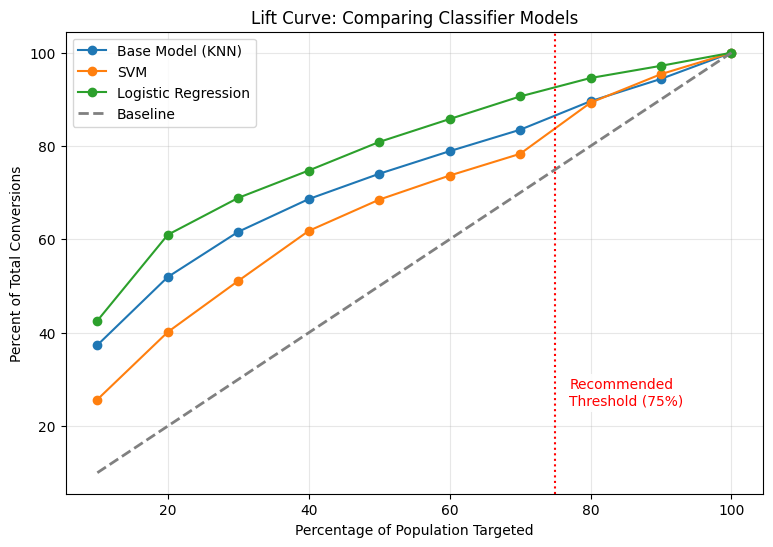

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import os
import textwrap # Import textwrap

def calculate_cumulative_conversions(y_true, y_prob, n_bins=10):
    df = pd.DataFrame({
        'actual': np.array(y_true),
        'probability': np.array(y_prob)
    })

    # Rank from highest predicted probability to lowest
    df = df.sort_values('probability', ascending=False).reset_index(drop=True)

    # Divide into deciles
    df['bin'] = pd.qcut(
        df.index,
        q=n_bins,
        labels=False,
        duplicates='drop'
    ) + 1

    # % of conversions in each bin
    total_conversions = df['actual'].sum()
    conversions = df.groupby('bin')['actual'].sum()

    # Cumulative number of conversions
    cumulative_conversions = conversions.cumsum()/total_conversions*100

    return cumulative_conversions


# Calculate predicted probabilities
knn_prob = knn_model.predict_proba(X_test)[:, 1]
svm_prob = svm.predict_proba(X_test)[:, 1]
# logit_prob = log_reg2.predict_proba(X_test_scaled)[:,1]
logit3_prob = log_reg3.predict(X_test3)

# Calculate lift
knn_lift = calculate_cumulative_conversions(y_test, knn_prob)
svm_lift = calculate_cumulative_conversions(y_test, svm_prob)
# logit_lift = calculate_cumulative_conversions(y_test, logit_prob)
logit3_lift = calculate_cumulative_conversions(y_test3, logit3_prob)

# Plot lift curves
x = np.arange(1, 11) * 10

fig = plt.figure(figsize=(9, 6))

plt.plot(x, knn_lift, marker='o', label='Base Model (KNN)')
plt.plot(x, svm_lift, marker='o', label='SVM')
# plt.plot(x, logit_lift, marker='o', label='Logistic Regression')
plt.plot(x, logit3_lift, marker='o', label='Logistic Regression')
total_conversions = np.sum(y_test)
baseline = total_conversions*(x / 100)/total_conversions*100
plt.plot(
    x,
    baseline,
    linestyle='--',
    linewidth=2,
    color='gray',
    label='Baseline'
)

plt.xlabel('Percentage of Population Targeted')
plt.ylabel('Percent of Total Conversions')
plt.title('Lift Curve: Comparing Classifier Models')
plt.legend()
plt.grid(True, alpha=0.3)
plt.axvline(x=75, color='red', linestyle=':')
bbox=dict(boxstyle="square,pad=0.3", alpha=0.9, facecolor="white", edgecolor='none') # Added edgecolor='none'

text_to_display = 'Recommended Threshold (75%)'
wrapped_text_to_display = textwrap.fill(text_to_display, width=15) # Wrap text to limit width

plt.text(77, 25, wrapped_text_to_display, color='red',
         fontsize=10, wrap=True, bbox=bbox)

# Create the 'media' directory if it doesn't exist
if not os.path.exists('media'):
    os.makedirs('media')

# fig.savefig('/content/media/my_plot.png', dpi=300, bbox_inches='tight')
fig.savefig('media/lift_curve.png', dpi=300, bbox_inches='tight')

In [ ]:
# Get coefficients and standard errors out of the chosen Logistic Regression model

# Coefficients
feature_names = X_train_scaled.columns
coefficients = log_reg2.coef_[0]
feature_names_with_intercept = ['const'] + list(feature_names)
coefficients_with_intercept = np.insert(coefficients, 0, log_reg2.intercept_[0])
print(feature_names_with_intercept)

# Create matrix with intercept
X = np.column_stack([
    np.ones(len(X_train_scaled)),
    X_train_scaled.values
])

# Variance-covariance matrix
p = log_reg2.predict_proba(X_train_scaled)[:,1]
W = np.diag(p * (1 - p))
cov_matrix = np.linalg.inv(X.T @ W @ X)

# Standard errors
standard_errors = np.sqrt(np.diag(cov_matrix))

# z-statistics
z_stats = coefficients_with_intercept / standard_errors

# Two-sided p-values
from scipy.stats import norm
p_values = 2 * (1 - norm.cdf(np.abs(z_stats)))

# Create results table
logit_results = pd.DataFrame({
    'Feature': feature_names_with_intercept,
    'Coefficient': coefficients_with_intercept,
    'Std Error': standard_errors,
    'z': z_stats,
    'P>|z|': p_values
})

# Sort by absolute coefficient, keeping constant first
logit_results = pd.concat([
    logit_results[logit_results['Feature'] == 'const'],
    logit_results[logit_results['Feature'] != 'const']
        .assign(abs_coef=lambda x: x['Coefficient'].abs())
        .sort_values('abs_coef', ascending=False)
        .drop(columns='abs_coef')
], ignore_index=True)

print(logit_results)


                        Feature  Coefficient  Std Error         z  \
0                         const    -0.758595        NaN       NaN   
1                  emp.var.rate    -2.099111   0.241799 -8.681236   
2                     month_mar     1.145724        NaN       NaN   
3                cons.price.idx     1.034073   0.158173  6.537608   
4              poutcome_failure    -0.888646        NaN       NaN   
..                          ...          ...        ...       ...   
58  education_university.degree    -0.015255        NaN       NaN   
59                   job_admin.     0.011415        NaN       NaN   
60            job_self-employed    -0.003957        NaN       NaN   
61              day_of_week_thu    -0.003511        NaN       NaN   
62                          age     0.002674   0.002619  1.020974   

           P>|z|  
0            NaN  
1   0.000000e+00  
2            NaN  
3   6.251066e-11  
4            NaN  
..           ...  
58           NaN  
59           NaN  
